# Analyse des données avec des requêtes SQL
Après le nettoyage de notre dataset, cette partie a pour but l'analyse des données avec l'utilisation de quelques requêtes SQL puis leur visualisation avec matplotlib.

**Ici j'analyse mon dataset sous trois angles différentes**
- Requête 1 (Dimension Qualité): satisfaction des patients par médicament et condition, lié à la pharmacovigilance et l'évaluation thérapeutique.
- Requête 2 (Dimension Temporelle) : évolution de l'engagement patient sur 2008-2017, pour anticiper les tendances et adapter les stratégies.
- Requête 3 (Dimension Impact) : mesure de l'utilité et de l'intérêt générés, pour identifier quels médicaments nécessitent plus de support et de communication patient.

In [39]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
# chargement de notre dataset déja nettoyer
df = pd.read_csv('../data/drugsComTrain_clean.csv')
df.shape
df.head(6)

,drugName,condition,review,rating,date,usefulCount
0,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,2012-05-20,27
1,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,2010-04-27,192
2,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,2009-12-14,17
3,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,2015-11-03,10
4,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,2016-11-27,37
5,Cialis,Benign Prostatic Hyperplasia,"""2nd day on 5mg started to work with rock hard...",2,2015-11-28,43


In [41]:
conn = sqlite3.connect('../data/drugsComTrain_clean.db')
df.to_sql('reviews', conn, if_exists='replace', index=False)
print("les données sont chargées dans SQLite :", df.shape)

les données sont chargées dans SQLite : (161297, 6)


**Requête 1: Les Médicaments les mieux notés par condition**

In [42]:
req1 = pd.read_sql_query("""
    SELECT AVG(rating) as note_moyenne, drugName, condition, COUNT(*) as nb_avis
    FROM reviews 
    WHERE condition != 'Unknown' 
    GROUP BY drugName, condition 
    HAVING COUNT(*) >= 30  
    ORDER BY note_moyenne DESC
    Limit 10 
""", conn)
print (req1)

   note_moyenne                                           drugName  \
0     10.000000                                Silver sulfadiazine   
1      9.673797                                        Propranolol   
2      9.565217                                   Chlordiazepoxide   
3      9.537313                                            Librium   
4      9.466667                                           Stribild   
5      9.454545                                           Tramadol   
6      9.433962  Cobicistat / elvitegravir / emtricitabine / te...   
7      9.420290                     Chlorpheniramine / hydrocodone   
8      9.416667                                            Demerol   
9      9.309524                                     Diethylpropion   

            condition  nb_avis  
0     Burns, External       35  
1       mance Anxiety      187  
2  Alcohol Withdrawal       69  
3  Alcohol Withdrawal       67  
4       HIV Infection       60  
5             Anxiety       33 

**visualisation requête 1**

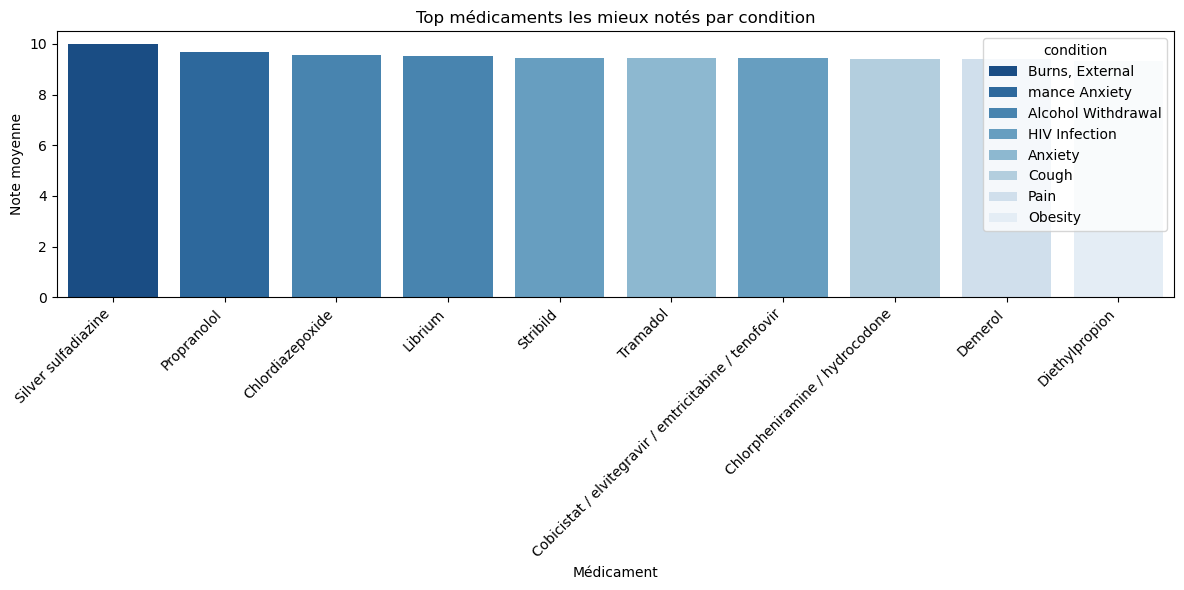

In [43]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=req1,
    x='drugName',
    y='note_moyenne',
    hue='condition',
    palette='Blues_r'
)
plt.title('Top médicaments les mieux notés par condition')
plt.xlabel('Médicament')
plt.ylabel('Note moyenne')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../dashboard/top_drugs_by_condition.png')
plt.show()

Les résultats identifient les médicaments les mieux perçus par les patients pour chaque condition médicale. Ces données constituent un signal de satisfaction patient utile pour orienter les stratégies de communication et de développement produit.

Cependant, ces conclusions restent limitées au ressenti patient et ne se substituent pas aux essais cliniques. En entreprise pharma, ces insights seraient croisés avec des données cliniques pour identifier les molécules les plus prometteuses à cibler dans les programmes de R&D. C'est ce qu'on appelle **le benchmarking thérapeutique**.

**Requête 2: Evolution des avis dans le temps**

In [44]:
req2 = pd.read_sql_query("""
    SELECT 
        strftime('%Y', date) as annee,
        COUNT(*) as nb_avis,
        AVG(rating) as note_moyenne
    FROM reviews
    GROUP BY annee
    ORDER BY annee ASC
""", conn)

print(req2)

  annee  nb_avis  note_moyenne
0  2008     5137      8.948024
1  2009    11636      7.437521
2  2010     8413      7.416498
3  2011    11682      7.483650
4  2012    10007      7.547117
5  2013    12278      8.071999
6  2014    12051      8.000913
7  2015    27164      6.929760
8  2016    34842      6.210235
9  2017    28087      6.058888


**Visualisation requête 2**

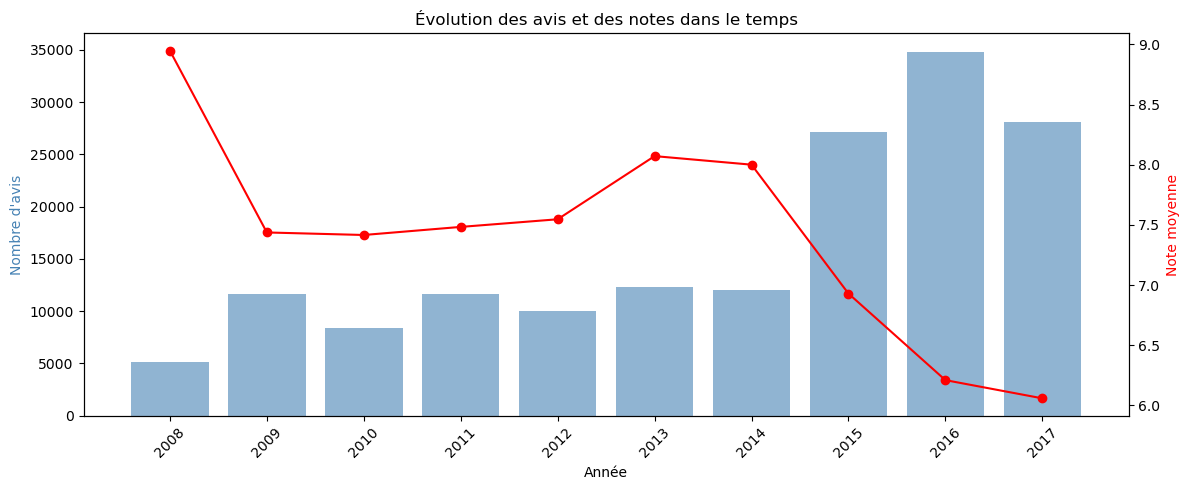

In [45]:
fig, ax1 = plt.subplots(figsize=(12, 5))

# Axe 1 — nombre d'avis
ax1.bar(req2['annee'], req2['nb_avis'], color='steelblue', alpha=0.6, label="Nb d'avis")
ax1.set_xlabel('Année')
ax1.set_ylabel("Nombre d'avis", color='steelblue')
ax1.tick_params(axis='x', rotation=45)

# Axe 2 — note moyenne
ax2 = ax1.twinx()
ax2.plot(req2['annee'], req2['note_moyenne'], color='red', marker='o', label='Note moyenne')
ax2.set_ylabel('Note moyenne', color='red')

plt.title("Évolution des avis et des notes dans le temps")
fig.tight_layout()
plt.savefig('../dashboard/evolution_temporelle.png')
plt.show()

Le dataset révèle une corrélation inverse entre **le nombre d'avis** et **les notes moyennes**. En **2008**, les rares avis affichent des notes 
proches de **9/10**, reflétant un biais de sélection : seuls les patients très satisfaits ou très engagés publiaient des avis en ligne à cette 
époque. En **2016**, l'explosion du volume d'avis (pic d'activité) s'accompagne d'une baisse de la note moyenne à **6.3/10**, traduisant une démocratisation de la parole patient et un biais de la plainte plus marqué. les patients insatisfaits étant davantage motivés à 
partager leur expérience.
Cette tendance souligne l'importance de ne jamais interpréter les notes moyennes sans tenir compte du volume et du contexte temporel 
des données.

**Requête 3: Top médicaments par nombre d'avis utiles**

In [46]:
req3 = pd.read_sql_query("""
    SELECT 
        drugName,
        SUM(usefulCount) as total_utile,
        AVG(usefulCount) as moyenne_utile,
        COUNT(*) as nb_avis,
        AVG(rating) as note_moyenne
    FROM reviews
    GROUP BY drugName
    HAVING COUNT(*) >= 30
    ORDER BY total_utile DESC
    LIMIT 10
""", conn)

print(req3)

       drugName  total_utile  moyenne_utile  nb_avis  note_moyenne
0    Sertraline        58154      42.760294     1360      7.497794
1    Gabapentin        56249      53.723973     1047      7.438395
2  Escitalopram        52280      40.464396     1292      7.843653
3     Bupropion        50542      49.454012     1022      7.445205
4       Lexapro        48328      50.764706      952      7.808824
5    Citalopram        47315      47.552764      995      7.666332
6        Zoloft        47309      58.768944      805      7.632298
7   Phentermine        46494      30.132210     1543      8.786131
8    Duloxetine        41304      44.222698      934      6.638116
9    Fluoxetine        40322      52.639687      766      7.633159


**Visualisation requête 3**

C:\Users\marie\AppData\Local\Temp\ipykernel_6120\327510223.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


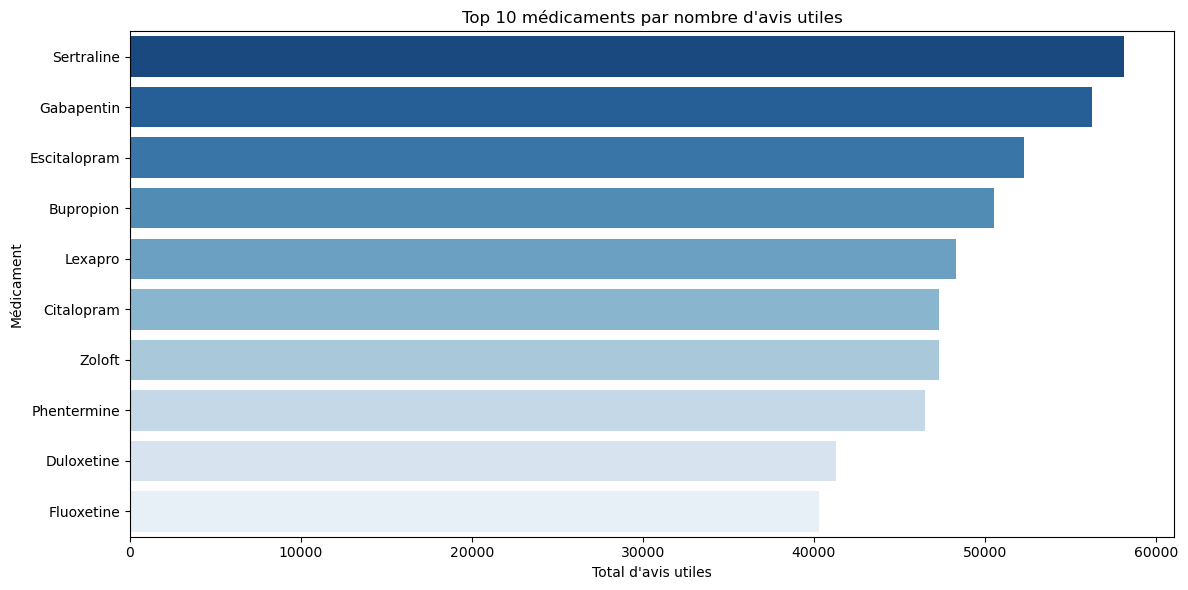

In [48]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=req3,
    x='total_utile',
    y='drugName',
    palette='Blues_r'
)
plt.title("Top 10 médicaments par nombre d'avis utiles")
plt.xlabel("Total d'avis utiles")
plt.ylabel('Médicament')
plt.tight_layout()
plt.savefig('../dashboard/top_drugs_utiles.png')
plt.show()

**Requête 3 par condition**

In [49]:
req3_detail = pd.read_sql_query("""
    SELECT 
        drugName,
        condition,
        SUM(usefulCount) as total_utile,
        COUNT(*) as nb_avis,
        AVG(rating) as note_moyenne
    FROM reviews
    WHERE condition != 'Unknown'
    GROUP BY drugName, condition
    HAVING COUNT(*) >= 30
    ORDER BY total_utile DESC
    LIMIT 10
""", conn)
print(req3_detail)

       drugName           condition  total_utile  nb_avis  note_moyenne
0   Phentermine         Weight Loss        39137     1211      8.799339
1     Bupropion          Depression        31101      549      7.358834
2    Citalopram  Anxiety and Stress        25233      417      7.685851
3    Sertraline          Depression        23596      459      7.167756
4        Zoloft          Depression        23163      281      7.281139
5  Etonogestrel       Birth Control        21885     3314      5.808992
6    Lorcaserin         Weight Loss        21707      387      7.919897
7        Belviq         Weight Loss        21440      381      7.858268
8     Buspirone             Anxiety        20364      407      6.164619
9     Trazodone            Insomnia        20092      382      6.850785


Les pathologies générant le plus d'avis utiles sont principalement **la dépression**, **l'anxiété** et **la perte de poids**, avec des notes moyennes autour de **7/10**. 
Ce résultat reflète la complexité de ces traitements : les patients cherchent activement des témoignages détaillés avant et pendant leur traitement, car les réponses thérapeutiques sont très variables d'un individu à l'autre. L'engagement élevé malgré une note modérée suggère un fort besoin de communication patient et de support médical pour ces pathologies, information directement actionnable pour les équipes médicales et marketing d'une entreprise pharmaceutique.

In [50]:
conn.close()